In [1]:
import numpy as np
from pulser import Register, Sequence, Pulse
from pulser import waveforms
from pulser.devices import MockDevice
from pulser_simulation import QutipEmulator

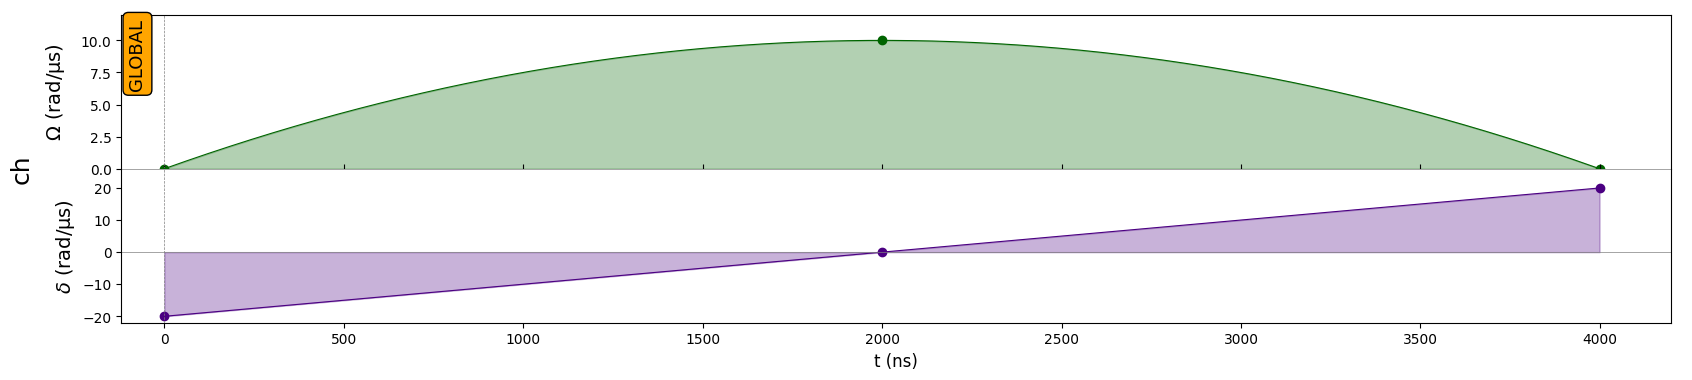

In [ ]:
# Initialize the register
reg = Register({
  "q1": (0, 0),
  "q2": (3, 5.2),
  "q3": (6, 0),
  "q4": (9, -5.2),
  "q5": (9, 0),
  "q6": (9, 5.2),
  "q7": (9, 10.4),
  "q8": (12, 0),
})

seq = Sequence(reg, MockDevice)

seq.declare_channel('ch', 'rydberg_global')

amplitude = waveforms.InterpolatedWaveform(4000, [0,10,0])
detuning = waveforms.InterpolatedWaveform(4000, [-20,0,20])
pulse = Pulse(amplitude, detuning, 0)

seq.add(pulse, 'ch')
seq.draw()

In [14]:
# MIS problem solver function
def MIS_solver(reg, T):
    seq = Sequence(reg, MockDevice)
    seq.declare_channel('ch', 'rydberg_global')
    amplitude = waveforms.InterpolatedWaveform(T, [0,10,0])
    detuning = waveforms.InterpolatedWaveform(T, [-20,0,20])
    pulse = Pulse(amplitude, detuning, 0)
    seq.add(pulse, 'ch')
    sim = QutipEmulator.from_sequence(seq)
    result = sim.run()
    return result.sample_final_state(1000)

Initial State: 


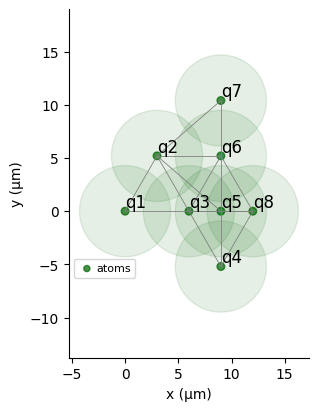

10010010
1 iteration


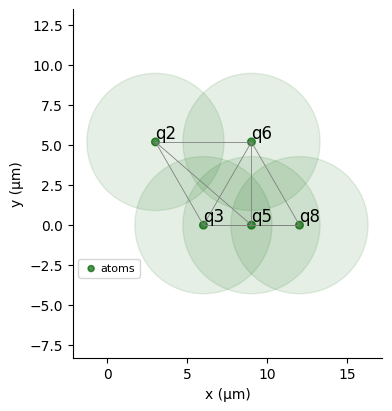

Counter({'10010010': 702, '10000011': 296, '00010010': 1, '01000001': 1})
10001
2 iteration


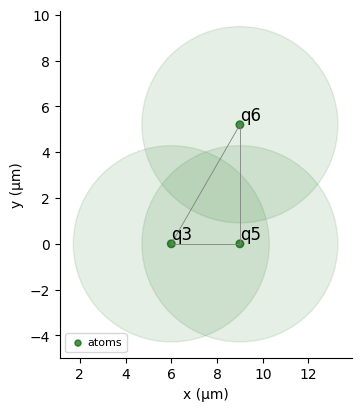

Counter({'10001': 1000})
100
3 iteration


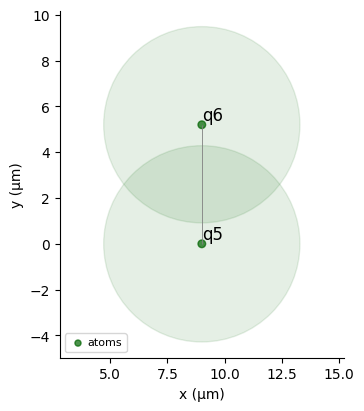

Counter({'100': 370, '001': 346, '010': 284})
10
4 iteration


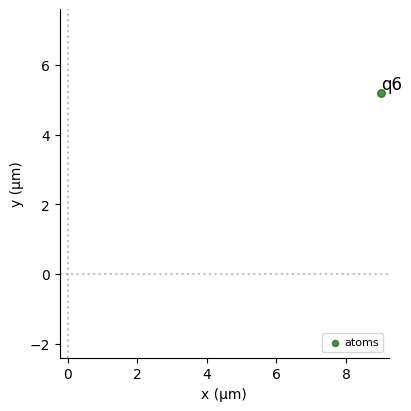

4

In [49]:
names = ["q1", "q2", "q3", "q4", "q5", "q6", "q7" , "q8"]
li = [(0, 0),(3, 5.2),(6,0),(9, -5.2),(9, 0), (9, 5.2), (9, 10.4),(12, 0)]

T = 10000
dict = {
  "q1": (0, 0),
  "q2": (3, 5.2),
  "q3": (6, 0),
  "q4": (9, -5.2),
  "q5": (9, 0),
  "q6": (9, 5.2),
  "q7": (9, 10.4),
  "q8": (12, 0),
}

def dividing_graph(dict, T):
  interference = 8.7 * np.pi / 2
  R_interatomic = MockDevice.rydberg_blockade_radius(interference)
  results = "00000"
  i = 0
  reg = Register(dict)
  while len(dict) > 1:
    if i == 0:
      print("Initial State: ")
      reg.draw(blockade_radius=R_interatomic, draw_half_radius=True)
    results = MIS_solver(reg, T)
    result = max(results) # We take the most probable outcome
    print(result)
    deleted = 0
    for j in range(len(result)):
      if result[j] == "1": # Pop every antennas associated with qubits in the 1 state
        dict.pop(names[j - deleted])
        li.pop(j - deleted)
        names.pop(j - deleted)
        deleted += 1
    reg = Register(dict)
    i += 1
    print(str(i) + " iteration")
    if len(dict) != 1:
      reg.draw(blockade_radius=R_interatomic, draw_half_radius=True)
    else:
      reg.draw()
      return i + 1 # returns the number of colors + the one for the single remaining qubit
    print(results)
  return  i # Return the number of iterations (the number of different frequencies required)
dividing_graph(dict,10000)
